Chapter 27
# 二元概率密度估计
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [5]:
import matplotlib.pyplot as plt 

In [7]:
# 定义可视化函数
def plot_surface(xx1, xx2, surface, x1_s, x2_s, 
                 z_height, color, title_txt):

    fig = plt.figure(figsize=(8,3))
    
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    ax.plot_wireframe(xx1, xx2, surface,
                      cstride = 8, rstride = 8,
                      color = [0.7,0.7,0.7],
                      linewidth = 0.25)
    ax.scatter(x1_s, x2_s, x2_s*0, c=color)
    ax.contour(xx1, xx2, surface,20,
                 cmap = 'RdYlBu_r')
    
    ax.set_proj_type('ortho')
    ax.set_xlabel('petal length, $x_1$')
    ax.set_ylabel('petal width, $x_2$')
    ax.set_zlabel('PDF')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlim(x1.min(), x1.max())
    ax.set_ylim(x2.min(), x2.max())
    ax.set_zlim([0,z_height])
    ax.view_init(azim=-120, elev=30)
    ax.set_title(title_txt)
    ax.grid(False)
    
    ax = fig.add_subplot(1, 2, 2)
    ax.contourf(xx1, xx2, surface, 12, cmap='RdYlBu_r')
    ax.contour(xx1, xx2, surface, 12, colors='w')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(x1.min(), x1.max())
    ax.set_ylim(x2.min(), x2.max())
    ax.set_xlabel('petal length, $x_1$')
    ax.set_ylabel('petal width, $x_2$')
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title_txt)

In [9]:
import numpy as np
import statsmodels.api as sm
import pandas as pd  
from sklearn.datasets import load_iris
import scipy.stats as st

In [11]:
# 导入鸢尾花数据
iris = load_iris()
X_1_to_4 = iris.data; y = iris.target

In [55]:
feature_names = ['Sepal length, $X_1$','Sepal width, $X_2$',
                 'Petal length, $X_3$','Petal width, $X_4$']

X_df = pd.DataFrame(X_1_to_4)
#提取后两列
X3_4_df = X_df.iloc[:,[2,3]]
X3_4_df

,2,3
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [39]:
x1 = np.linspace(0,10,201); x2 = np.linspace(0,10,201)
xx1, xx2 = np.meshgrid(x1,x2)
positions = np.vstack([xx1.ravel(), xx2.ravel()])
colors = ['#FF3300','#0099FF','#8A8A8A']

In [41]:
KDE = st.gaussian_kde(X3_4_df.values.T)
f_x1_x2 = np.reshape(KDE(positions).T, xx1.shape)

In [43]:
x1_s = X3_4_df.iloc[:,0]
x2_s = X3_4_df.iloc[:,1]

In [45]:
# 可视化证据因子

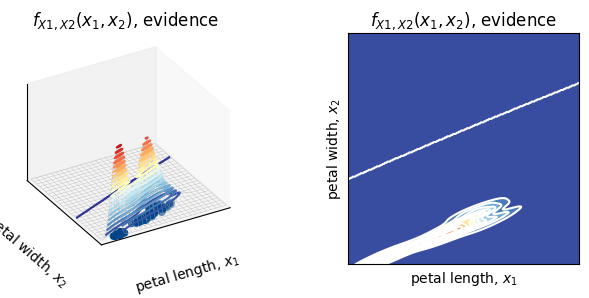

In [47]:
z_height = 0.5
title_txt = '$f_{X1, X2}(x_1, x_2)$, evidence'
plot_surface(xx1, xx2, f_x1_x2, 
             x1_s, x2_s, z_height, 
             '#00448A', title_txt)

In [49]:
# 可视化似然函数

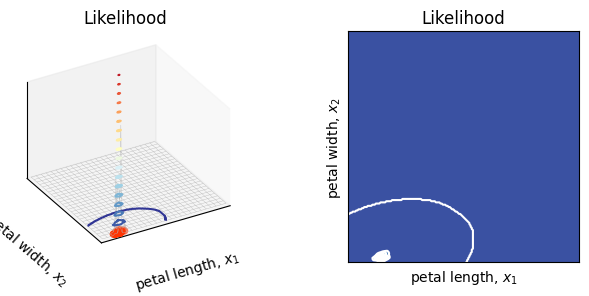

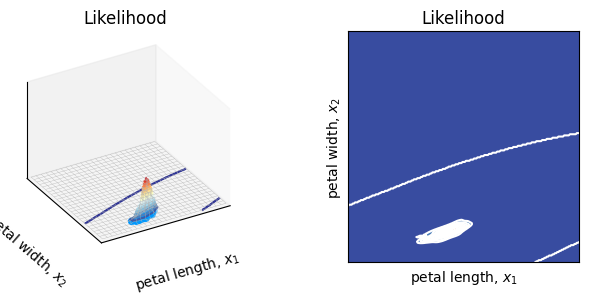

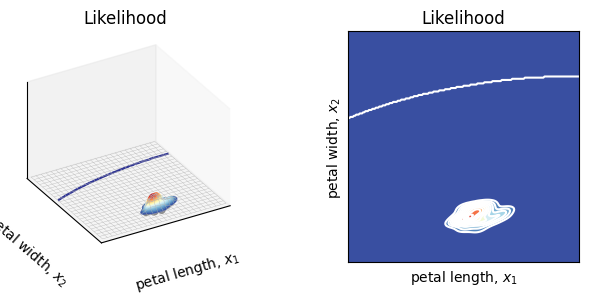

In [65]:
# 考虑不同鸢尾花分类
for idx in range(3):

    KDE_idx = st.gaussian_kde(X3_4_df[y==idx].values.T)
    f_x1_x2_given_C_i = np.reshape(KDE_idx(positions).T, xx1.shape)

    x1_s_C_i = X3_4_df.iloc[:,0][y==idx]
    x2_s_C_i = X3_4_df.iloc[:,1][y==idx]

    z_height = 6
    title_txt = 'Likelihood'
    plot_surface(xx1, xx2, f_x1_x2_given_C_i, 
                 x1_s_C_i, x2_s_C_i, z_height, 
                 colors[idx], title_txt)